
--- BASIC INFO ---
Shape: (1946, 32)

Data Types:
episode_id                                  int64
unique_patient_id                           int64
sex                                         int64
race                                       object
gestational_age_at_birth_weeks            float64
birth_weight_kg                           float64
sepsis_group                                int64
onset_age_in_days                           int64
onset_hour_of_day                           int64
blood_culture_positive                      int64
positive_days                               int64
cx_site                                   float64
time_to_antibiotics                         int64
stat_abx                                    int64
overall_mortality_within_7_days             int64
overall_mortality_within_14_days            int64
overall_mortality_within_30_days            int64
intubated_at_time_of_sepsis_evaluation      int64
intubated_free_days                         int64

,episode_id,unique_patient_id,sex,race,gestational_age_at_birth_weeks,birth_weight_kg,sepsis_group,onset_age_in_days,onset_hour_of_day,blood_culture_positive,...,umbilical_arterial_line,ecmo,temp_celsius,length_of_stay_hours,comorbidity_necrotizing_enterocolitis,comorbidity_chronic_lung_disease,comorbidity_cardiac,comorbidity_surgical,comorbidity_ivh_or_shunt,period
0,1,1,0,3,23.0,0.40,1,7,9,1,...,1,0,37.6,216.0,0,0,0,0,1,Year 1
1,2,2,0,5,27.0,0.79,3,0,4,0,...,1,0,36.8,578.0,0,0,0,0,0,Year 1
2,3,2,0,5,27.0,0.79,1,23,9,1,...,0,0,36.9,578.0,0,0,0,0,0,Year 1
3,4,3,0,5,37.0,4.31,1,11,22,1,...,1,0,37.2,285.0,0,0,0,0,0,Year 1
4,5,4,1,5,39.0,4.17,2,3,17,0,...,1,0,36.2,783.0,0,0,0,0,0,Year 1



--- MISSING VALUES (Count & %) ---


,Missing_Count,Missing_%
cx_site,1752,90.030832
length_of_stay_hours,108,5.549846
birth_weight_kg,52,2.672148
gestational_age_at_birth_weeks,15,0.770812
temp_celsius,4,0.205550
sex,0,0.000000
race,0,0.000000
episode_id,0,0.000000
onset_age_in_days,0,0.000000
onset_hour_of_day,0,0.000000


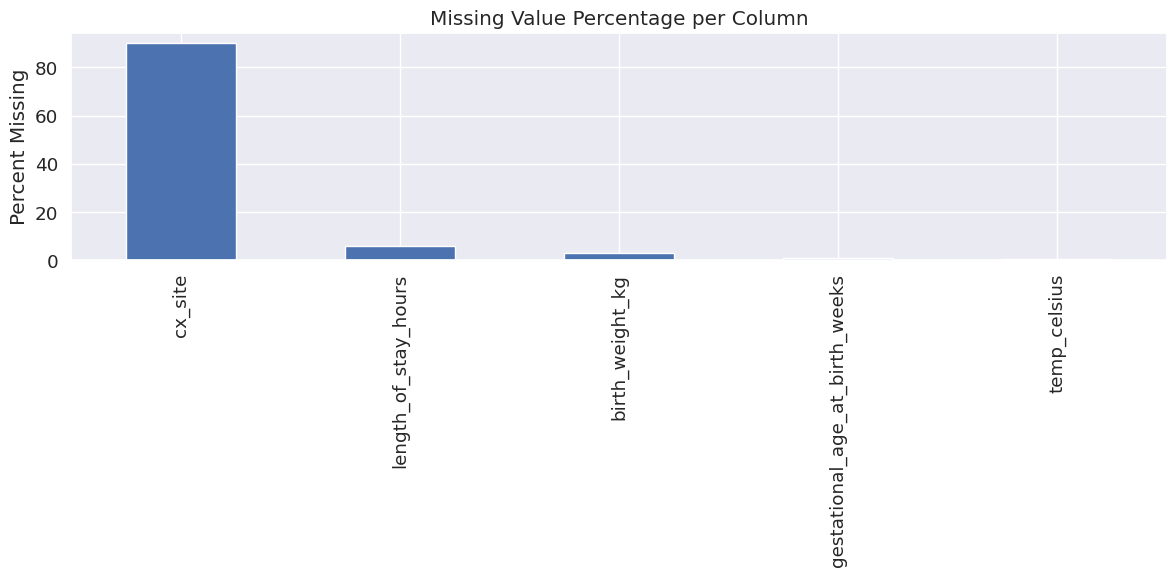


--- TARGET VARIABLE: sepsis_group ---
sepsis_group
2    1141
3     361
1     194
6     169
4      71
5      10
Name: count, dtype: int64


/tmp/ipython-input-3259847251.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sepsis_group", palette="viridis")


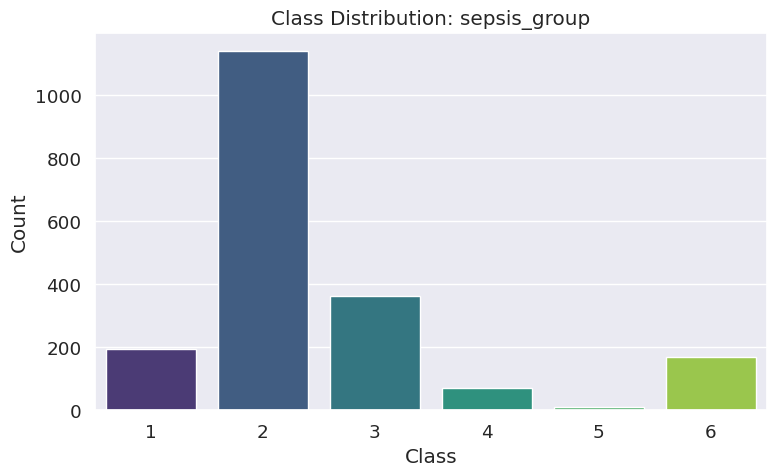


--- NUMERIC COLUMN SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
episode_id,1946.0,973.500000,561.906131,1.00,487.25,973.50,1459.75,1946.00
unique_patient_id,1946.0,491.026721,272.736848,1.00,264.00,481.50,730.75,986.00
sex,1946.0,0.576567,0.494230,0.00,0.00,1.00,1.00,1.00
gestational_age_at_birth_weeks,1931.0,32.336095,5.341832,22.00,27.00,34.00,37.00,41.00
birth_weight_kg,1894.0,2.009187,1.121012,0.37,0.88,2.04,2.95,5.95
sepsis_group,1946.0,2.521583,1.263201,1.00,2.00,2.00,3.00,6.00
onset_age_in_days,1946.0,66.431655,70.165333,0.00,10.00,44.00,105.75,335.00
onset_hour_of_day,1946.0,10.560123,6.533421,0.00,5.00,10.00,16.00,23.00
blood_culture_positive,1946.0,0.065776,0.247954,0.00,0.00,0.00,0.00,1.00
positive_days,1946.0,0.112539,0.541517,0.00,0.00,0.00,0.00,7.00



--- CATEGORICAL COLUMNS & UNIQUE VALUES ---

Column: race
race
5     799
0     563
3     464
6      59
2      46
1       8
NI      7
Name: count, dtype: int64

Column: period
period
Year 2    659
Year 3    587
Year 1    491
Year 4    209
Name: count, dtype: int64


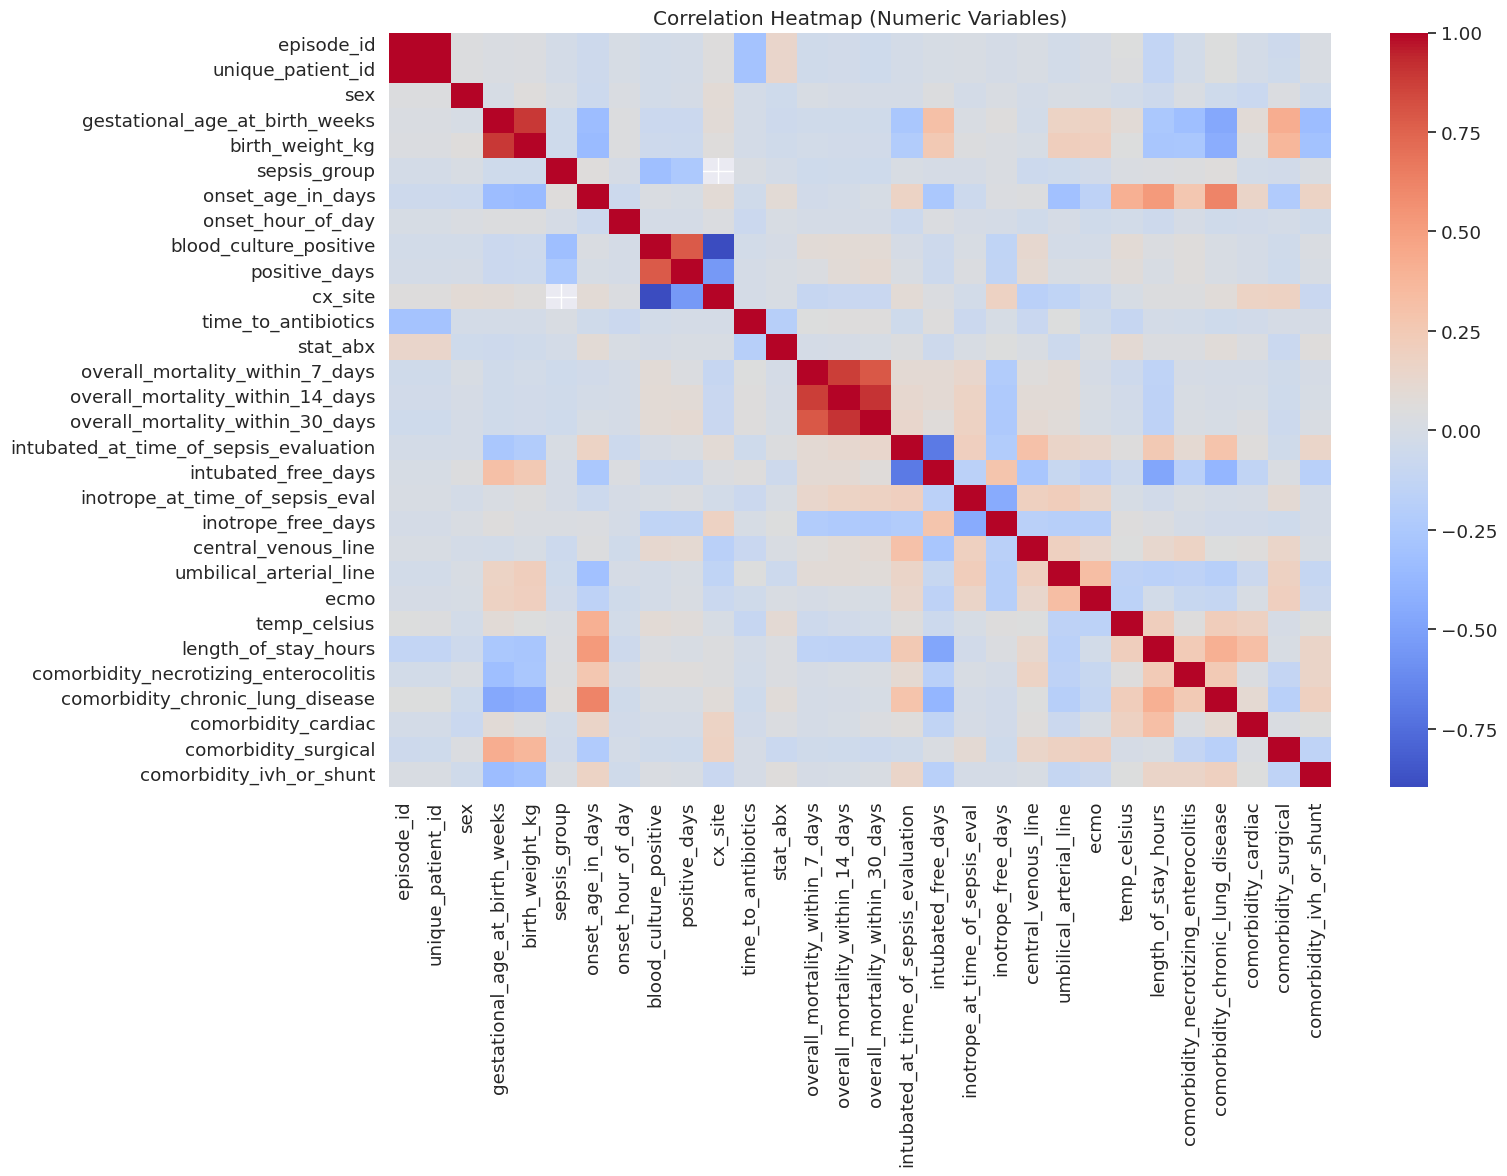

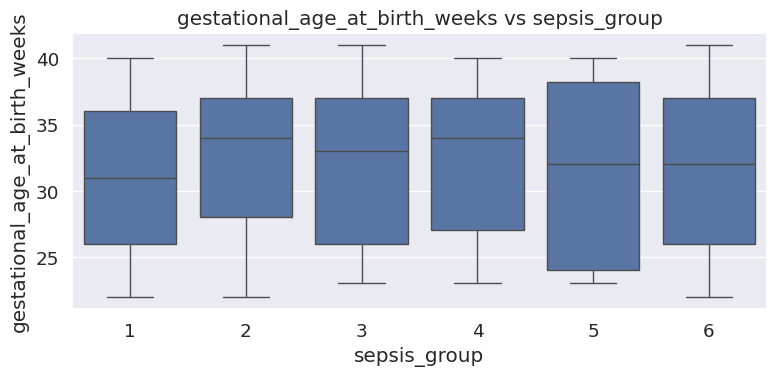

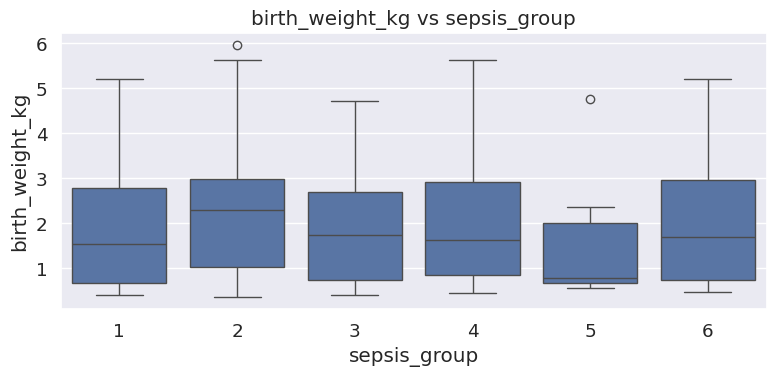

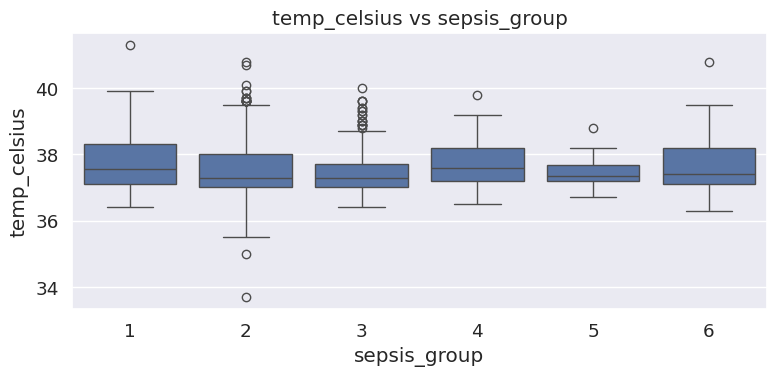

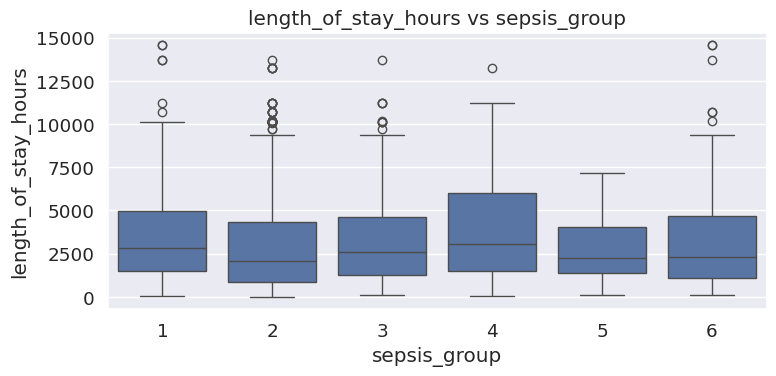

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.2)

df = pd.read_csv("deid-nicu-sepsis-tta.csv")

print("\n--- BASIC INFO ---")
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\n--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- MISSING VALUES (Count & %) ---")
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_%": missing_percent
})

display(missing_df)

plt.figure(figsize=(12, 6))
missing_percent[missing_percent > 0].plot(kind='bar')
plt.title("Missing Value Percentage per Column")
plt.ylabel("Percent Missing")
plt.tight_layout()
plt.show()

if "sepsis_group" in df.columns:
    print("\n--- TARGET VARIABLE: sepsis_group ---")
    print(df["sepsis_group"].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="sepsis_group", palette="viridis")
    plt.title("Class Distribution: sepsis_group")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\n--- NUMERIC COLUMN SUMMARY ---")
display(df[num_cols].describe().T)

cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("\n--- CATEGORICAL COLUMNS & UNIQUE VALUES ---")
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

plt.figure(figsize=(16, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()

important_numeric = ["gestational_age_at_birth_weeks", "birth_weight_kg",
                     "temp_celsius", "length_of_stay_hours"]

for col in important_numeric:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x="sepsis_group", y=col)
        plt.title(f"{col} vs sepsis_group")
        plt.tight_layout()
        plt.show()


In [ ]:
df_b = df.copy()

df_b = df_b[df_b["sepsis_group"].isin([1,2,3])]

label_map_B = {
    2: 0,
    3: 1,
    1: 2
}

df_b["label_B"] = df_b["sepsis_group"].map(label_map_B)

print("Class counts (Problem B):")
print(df_b["label_B"].value_counts())


Class counts (Problem B):
label_B
0    1141
1     361
2     194
Name: count, dtype: int64


In [ ]:

df_c = df.copy()

label_map_C = {
    2: 0,
    3: 1,
    1: 2,
    4: 3,
    5: 3,
    6: 3
}

df_c["label_C"] = df_c["sepsis_group"].map(label_map_C)

print("Class counts (Problem C):")
print(df_c["label_C"].value_counts())


Class counts (Problem C):
label_C
0    1141
1     361
3     250
2     194
Name: count, dtype: int64


In [ ]:
df_bin = df.copy()
df_bin["label_bin"] = (df_bin["sepsis_group"] != 2).astype(int)

print(df_bin["label_bin"].value_counts())


label_bin
0    1141
1     805
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

X = df_bin.drop(columns=["sepsis_group", "label_bin"])
y = df_bin["label_bin"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numeric Columns: ['episode_id', 'unique_patient_id', 'sex', 'gestational_age_at_birth_weeks', 'birth_weight_kg', 'onset_age_in_days', 'onset_hour_of_day', 'blood_culture_positive', 'positive_days', 'cx_site', 'time_to_antibiotics', 'stat_abx', 'overall_mortality_within_7_days', 'overall_mortality_within_14_days', 'overall_mortality_within_30_days', 'intubated_at_time_of_sepsis_evaluation', 'intubated_free_days', 'inotrope_at_time_of_sepsis_eval', 'inotrope_free_days', 'central_venous_line', 'umbilical_arterial_line', 'ecmo', 'temp_celsius', 'length_of_stay_hours', 'comorbidity_necrotizing_enterocolitis', 'comorbidity_chronic_lung_disease', 'comorbidity_cardiac', 'comorbidity_surgical', 'comorbidity_ivh_or_shunt']
Categorical Columns: ['race', 'period']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [ ]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    f1_score, roc_auc_score
)

lasso_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=500,
        class_weight=None
    ))
])

lasso_clf.fit(X_train, y_train)
y_pred_lasso = lasso_clf.predict(X_test)
y_proba_lasso = lasso_clf.predict_proba(X_test)[:, 1]

print("\n===== LASSO LOGISTIC REGRESSION (L1) =====\n")

print("Precision:", precision_score(y_test, y_pred_lasso))
print("Recall:", recall_score(y_test, y_pred_lasso))
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("F1 Score:", f1_score(y_test, y_pred_lasso))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lasso))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lasso))



===== LASSO LOGISTIC REGRESSION (L1) =====

Precision: 0.7532467532467533
Recall: 0.36024844720496896
Accuracy: 0.6871794871794872
F1 Score: 0.48739495798319327
ROC-AUC: 0.7230464617971737

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.92      0.77       229
           1       0.75      0.36      0.49       161

    accuracy                           0.69       390
   macro avg       0.71      0.64      0.63       390
weighted avg       0.70      0.69      0.66       390



In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    f1_score, roc_auc_score, classification_report
)

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====\n")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


In [ ]:
from sklearn.linear_model import LogisticRegression

lasso_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=500
    ))
])

lasso_clf.fit(X_train, y_train)
evaluate_model(lasso_clf, X_test, y_test, name="LASSO Logistic Regression (L1)")



===== LASSO Logistic Regression (L1) =====

Accuracy : 0.6871794871794872
Precision: 0.7532467532467533
Recall   : 0.36024844720496896
F1 Score : 0.48739495798319327
ROC-AUC  : 0.7230464617971737

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.92      0.77       229
           1       0.75      0.36      0.49       161

    accuracy                           0.69       390
   macro avg       0.71      0.64      0.63       390
weighted avg       0.70      0.69      0.66       390



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_clf.fit(X_train, y_train)
evaluate_model(rf_clf, X_test, y_test, name="Random Forest")



===== Random Forest =====

Accuracy : 0.6487179487179487
Precision: 0.6333333333333333
Recall   : 0.35403726708074534
F1 Score : 0.4541832669322709
ROC-AUC  : 0.6633079280696521

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.86      0.74       229
           1       0.63      0.35      0.45       161

    accuracy                           0.65       390
   macro avg       0.64      0.60      0.60       390
weighted avg       0.65      0.65      0.62       390



In [ ]:
from xgboost import XGBClassifier

xgb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_clf.fit(X_train, y_train)
evaluate_model(xgb_clf, X_test, y_test, name="XGBoost Classifier")



===== XGBoost Classifier =====

Accuracy : 0.6564102564102564
Precision: 0.6285714285714286
Recall   : 0.40993788819875776
F1 Score : 0.49624060150375937
ROC-AUC  : 0.6953809433399333

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.83      0.74       229
           1       0.63      0.41      0.50       161

    accuracy                           0.66       390
   macro avg       0.65      0.62      0.62       390
weighted avg       0.65      0.66      0.64       390



In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        max_iter=250,
        random_state=42
    ))
])

mlp_clf.fit(X_train, y_train)
evaluate_model(mlp_clf, X_test, y_test, name="MLP Neural Network")



===== MLP Neural Network =====

Accuracy : 0.6512820512820513
Precision: 0.5827814569536424
Recall   : 0.546583850931677
F1 Score : 0.5641025641025641
ROC-AUC  : 0.682660229461065

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.72      0.71       229
           1       0.58      0.55      0.56       161

    accuracy                           0.65       390
   macro avg       0.64      0.64      0.64       390
weighted avg       0.65      0.65      0.65       390



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.svm import SVC

svm_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_clf.fit(X_train, y_train)
evaluate_model(svm_clf, X_test, y_test, name="SVM (RBF Kernel)")



===== SVM (RBF Kernel) =====

Accuracy : 0.676923076923077
Precision: 0.7464788732394366
Recall   : 0.32919254658385094
F1 Score : 0.45689655172413796
ROC-AUC  : 0.6867422495863734

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.92      0.77       229
           1       0.75      0.33      0.46       161

    accuracy                           0.68       390
   macro avg       0.70      0.63      0.61       390
weighted avg       0.70      0.68      0.64       390



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

smote = SMOTE(random_state=42)

lasso_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", smote),
    ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=500))
])

rf_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", smote),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
])

xgb_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", smote),
    ("clf", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42))
])

mlp_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", smote),
    ("clf", MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", solver="adam", alpha=1e-4, max_iter=250, random_state=42))
])

svm_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", smote),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

lasso_smote.fit(X_train, y_train)
rf_smote.fit(X_train, y_train)
xgb_smote.fit(X_train, y_train)
mlp_smote.fit(X_train, y_train)
svm_smote.fit(X_train, y_train)

evaluate_model(lasso_smote, X_test, y_test, "LASSO + SMOTE")
evaluate_model(rf_smote, X_test, y_test, "Random Forest + SMOTE")
evaluate_model(xgb_smote, X_test, y_test, "XGBoost + SMOTE")
evaluate_model(mlp_smote, X_test, y_test, "MLP + SMOTE")
evaluate_model(svm_smote, X_test, y_test, "SVM + SMOTE")


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(



===== LASSO + SMOTE =====
Accuracy : 0.6717948717948717
Precision: 0.6299212598425197
Recall   : 0.4968944099378882
F1 Score : 0.5555555555555556
ROC-AUC  : 0.7186254034554775

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.79      0.74       229
           1       0.63      0.50      0.56       161

    accuracy                           0.67       390
   macro avg       0.66      0.65      0.65       390
weighted avg       0.67      0.67      0.66       390


===== Random Forest + SMOTE =====
Accuracy : 0.6461538461538462
Precision: 0.6017699115044248
Recall   : 0.422360248447205
F1 Score : 0.49635036496350365
ROC-AUC  : 0.6702785537985843

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.80      0.73       229
           1       0.60      0.42      0.50       161

    accuracy                           0.65       390
   macro avg       0.63      0.61      0.61

In [ ]:
from sklearn.metrics import precision_recall_curve

xgb_model.fit(X, y)

probs = xgb_model.predict_proba(X)[:,1]
prec, rec, thr = precision_recall_curve(y, probs)

f1_scores = 2*(prec*rec)/(prec+rec+1e-9)
best_idx = np.argmax(f1_scores)
best_thr = thr[best_idx]

print("Best Threshold:", best_thr)
print("Max Recall:", rec[best_idx])
print("Max F1:", f1_scores[best_idx])


Best Threshold: 0.5080123
Max Recall: 0.7850931677018633
Max F1: 0.6448979586996173


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

pred_xgb = xgb_model.predict_proba(X)[:,1]
pred_lasso = logistic_model.predict_proba(X)[:,1]
pred_mlp = mlp_model.predict_proba(X)[:,1]

meta_X = np.vstack([pred_xgb, pred_lasso, pred_mlp]).T

stacker = LogisticRegression(max_iter=500)
stacker.fit(meta_X, y)

stack_probs = stacker.predict_proba(meta_X)[:,1]
stack_preds = (stack_probs > 0.5).astype(int)

print("STACKED ACC:", accuracy_score(y, stack_preds))
print("STACKED PREC:", precision_score(y, stack_preds))
print("STACKED REC:", recall_score(y, stack_preds))
print("STACKED F1:", f1_score(y, stack_preds))
print("STACKED AUC:", roc_auc_score(y, stack_probs))


STACKED ACC: 0.9260020554984584
STACKED PREC: 0.9136420525657072
STACKED REC: 0.906832298136646
STACKED F1: 0.9102244389027432
STACKED AUC: 0.9524825667797127
